# I want to compare the speed of the 3 different solvers

In [17]:
from solvers import city_to_city_solver, gas_to_gas_solver
from or_solver import or_solver
import numpy as np
import matplotlib.pyplot as plt
import time

In [18]:
def generate_random_data(n_locations, max_distance, min_distance=50, low_gas=2.5, high_gas=7.0, gas_mu=4.5):
    
    if min_distance > max_distance:
        raise ValueError("min_distance cannot be greater than max_distance")
    
    # Generate distances
    distances = np.random.randint(min_distance, max_distance, size=n_locations)

    # Get gas from normal distribution
    gas = np.random.normal(gas_mu, 0.5, size=n_locations)
    gas = np.clip(gas, low_gas, high_gas)
    gas = np.round(gas, decimals=3)

    return np.array([distances, gas]).T

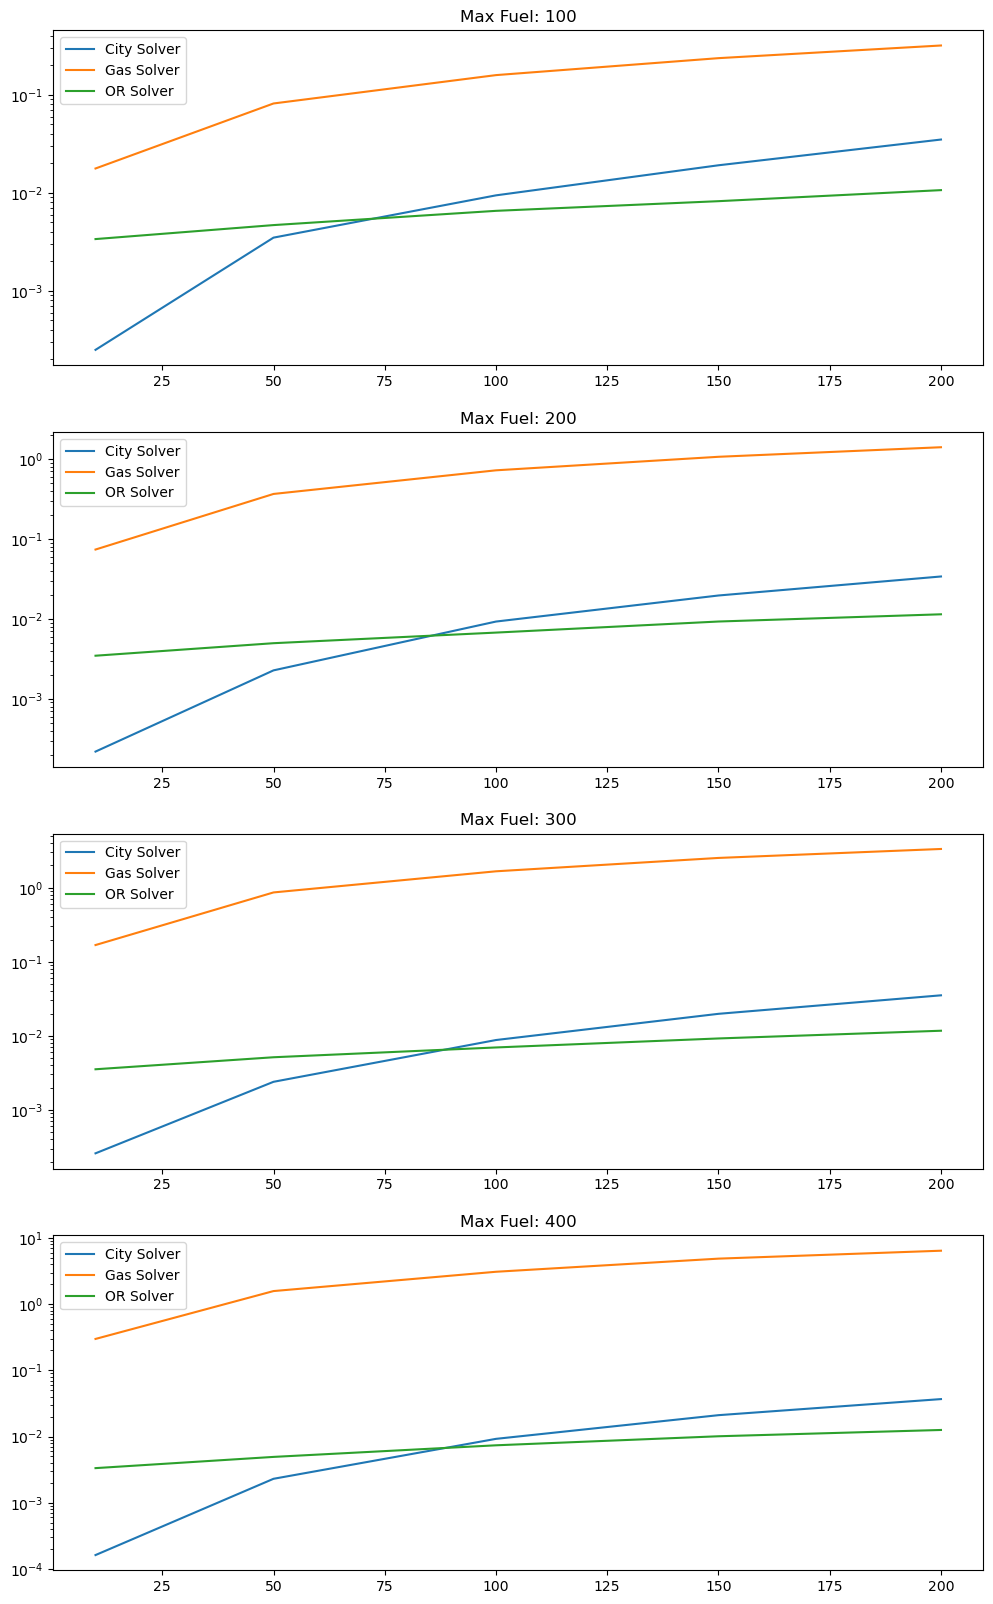

In [19]:
max_fuels_lists = [100, 200, 300, 400]
num_locations_lists = [10, 50, 100, 150, 200]
num_trials = 10

fig, ax = plt.subplots(len(max_fuels_lists), 1, figsize=(12, len(max_fuels_lists) * 5))
ax = ax.flatten()

for i, max_fuel in enumerate(max_fuels_lists):

    city_solver_times = [[] for _ in range(len(num_locations_lists))]
    gas_solver_times = [[] for _ in range(len(num_locations_lists))]
    or_solver_times = [[] for _ in range(len(num_locations_lists))]

    for j, num_locations in enumerate(num_locations_lists):
        for k in range(num_trials):
            data = generate_random_data(num_locations, max_fuel)

            start_time = time.time()
            city_s = city_to_city_solver(data, max_fuel)
            city_s.solve()
            city_solver_times[j].append(time.time() - start_time)
            
            start_time = time.time()
            gas_s = gas_to_gas_solver(data, max_fuel)
            gas_s.solve()
            gas_solver_times[j].append(time.time() - start_time)
            

            start_time = time.time()
            or_s = or_solver(data, max_fuel)
            or_s.solve()
            or_solver_times[j].append(time.time() - start_time)

    city_solver_times = np.array(city_solver_times)
    gas_solver_times = np.array(gas_solver_times)
    or_solver_times = np.array(or_solver_times)
    city_solver_times = np.mean(city_solver_times, axis=1)
    gas_solver_times = np.mean(gas_solver_times, axis=1)
    or_solver_times = np.mean(or_solver_times, axis=1)

    ax[i].plot(num_locations_lists, city_solver_times, label='City Solver')
    ax[i].plot(num_locations_lists, gas_solver_times, label='Gas Solver')
    ax[i].plot(num_locations_lists, or_solver_times, label='OR Solver')
    ax[i].legend()
    ax[i].set_yscale('log')
    ax[i].set_title(f'Max Fuel: {max_fuel}')